In [1]:
#Importar Librerias.

import os 
import ssl
import time
import random
import matplotlib.pyplot as plt
from docxtpl import DocxTemplate
from docx2pdf import convert
from gtts import gTTS
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.base import MIMEBase
from email import encoders
from abc import ABC, abstractmethod, ABCMeta 
from typing import List, Dict, Tuple, Optional, Any
from docx import Document

In [2]:
# Funcion para asegurar que exista una plantilla Word

def asegurar_plantilla():
    if not os.path.exists("template_informe.docx"):
        doc = Document()
        doc.add_heading("Informe de Mutaciones Geneticas", 0)
        doc.add_paragraph("Historial de Mutaciones Derectadas")
        doc.add_paragraph("{{historial}}")
        doc.save("template_informe.docx")
        print("Plantilla 'template_informe.docx' Generada Con Exito")
        
asegurar_plantilla()
print('Entorno bioinformatico generado con exito')

Entorno bioinformatico generado con exito


In [3]:
# Logica de control estructural y medicion de rendimiento.


def medir_tiempo_generacional(func):
    def wrapper(*args, **kwargs):
        inicio = time.process_time()
        resultado = func(*args, **kwargs)
        fin = time.process_time()
        print(f"Tiempo de CPU en ejecucion: {fin - inicio:.6f} segundos")
        return resultado

    return wrapper


class MetaEvolucion(ABCMeta):
    def __new__(cls, name, bases, dct):
        if name != "Organismo" and "calcular_tasa_mutacion" not in dct:
            raise TypeError(
                f"error: la clase {name} debe implementar 'calcular_tasa_mutacion()'"
            )
        return super().__new__(cls, name, bases, dct)


class Organismo(metaclass=MetaEvolucion):
    def __init__(self, nombre: str):
        self.nombre = nombre

    @abstractmethod
    def calcular_tasa_mutacion(self) -> float:
        pass


class VirusARN(Organismo):
    def __init__(self, nombre: str, secuencia: str):
        super().__init__(nombre)
        self.__secuencia_arn = secuencia.upper().replace("T", "U")

    @property
    def secuencia_arn(self) -> str:
        return self.__secuencia_arn

    @secuencia_arn.setter
    def secuencia_arn(self, nueva_secuencia: str):
        if all(base in "ACGU" for base in nueva_secuencia.upper()):
            self.__secuencia_arn = nueva_secuencia.upper()
        else:
            raise ValueError("Secuencia ARN no valida (Debe ser A, C, G, U)")

    def calcular_tasa_mutacion(self) -> float:
        return 0.08


class Bacteria(Organismo):
    def __init__(self, nombre: str, secuencia: str):
        super().__init__(nombre)
        self.__secuencia_adn = secuencia.upper()

    @property
    def secuencia_adn(self) -> str:
        return self.__secuencia_adn

    @secuencia_adn.setter
    def secuencia_adn(self, nueva_secuencia: str):
        if all(base in "ACGT" for base in nueva_secuencia.upper()):
            self.__secuencia_adn = nueva_secuencia.upper()
        else:
            raise ValueError("Secuencia ADN no valida (Debe ser A, C, G, T)")

    def calcular_tasa_mutacion(self) -> float:
        return 0.02
    

In [4]:

def simular_evolucion_patogeno(organismo: Organismo, coordenadas: Tuple[float, float]):
    "Funcion principal de simulacion genomica sobre 100 gereraciones"

    # Poblacion icial: Direccionario con llaves como tuplas geograficas
    secuencia_base = organismo.secuencia_arn if isinstance(organismo, VirusARN) else organismo.secuencia_adn
    poblacion: Dict[Tuple[float, float], List[str]] = {
        coordenadas: [secuencia_base] * 12
    }
    generacion = 1
    historial_mutaciones = []
    variantes_supercontagiosa = ""
    bases_posibles = "ACGU" if isinstance(organismo, VirusARN) else "ACGT"
    print(f"Iniciando simulacion para  {organismo.nombre} en {coordenadas} ...")

    while generacion <= 100:
        poblacion_actual = poblacion[coordenadas]
        nueva_poblacion = []
        # bucle de cruce (recombinacion de seciencias)

        for i in range(0, len(poblacion_actual), 2):
            if i + 1 >= len(poblacion_actual):
                break

            # cruce de ADN: conversion str -> lista -> str

            adn1, adn2 = list(poblacion_actual[i]), list(poblacion_actual[i + 1])
            punto_corte = random.randint(1, len(adn1) - 1)

            # formamos dos descendientes por cada pareja

            hijo1 = adn1[:punto_corte] + adn2[punto_corte:]
            hijo2 = adn2[:punto_corte] + adn1[punto_corte:]

            for descendiente in [hijo1, hijo2]:
                estres_ambiental = random.random()

                # clasificacion de mutaciones mediante  if-elif-else
                if estres_ambiental < 0.015:
                    # letal: se elimina del pool genetico
                    continue
                elif estres_ambiental < 0.07:
                    # supercontagiosa: mutacion forzada agresiva
                    idx = random.randint(0, len(descendiente) - 1)
                    descendiente[idx] = random.choice(bases_posibles)
                    variantes_supercontagiosa = "".join(descendiente)
                    tipo = "supercontagiosa"
                else:
                    # inofensiva / neutral basada en porbabilidad del organismo
                    tipo = "inofensiva"
                    if random.random() < organismo.calcular_tasa_mutacion():
                        idx = random.randint(0, len(descendiente) - 1)
                        descendiente[idx] = random.choice(bases_posibles)

                nueva_poblacion.append("".join(descendiente))
                if generacion % 10 == 0:
                    historial_mutaciones.append(f"Gen {generacion}: {tipo}")
        # evitar extincion total
        if not nueva_poblacion:
            nueva_poblacion = [secuencia_base] * 12
        poblacion[coordenadas] = nueva_poblacion
        generacion += 1

    return variantes_supercontagiosa or poblacion[coordenadas][0], historial_mutaciones

In [5]:

def generar_visalizacion(secuencia: str, path: str):
    "crea graficos de barras apiladas con la distribucion de baes (A,C,G, T/U)"

    os.makedirs(path, exist_ok=True)
    bases_lista = "ACGU" if "U" in secuencia else "ACGT"
    conteo = {base: secuencia.count(base) for base in bases_lista}

    plt.figure(figsize=(8, 6))
    bottom = 0
    colores = {"A": "red", "C": "blue", "G": "green", "T": "yellow", "U": "purple"}

    for base in bases_lista:
        plt.bar(
            "Variante detectado",
            conteo[base],
            bottom=bottom,
            label=f"Base {base}",
            color=colores[base],
        )
        bottom += conteo[base]

    plt.title("distribucion genomica: Variante Supercontagiosa")
    plt.ylabel("Frecuencia de Bases")
    plt.legend()
    plt.savefig(os.path.join(path, "grafico_genomico.png"))
    plt.show()
    print(f"Visualizacion guardada en : {path}")

In [6]:
def generar_entregables(historial: List[str], path: str):
    "inyecta fatos en word,  intenta pdf y genera audio gTTS"

    try:
        doc = DocxTemplate("template_informe.docx")
        doc.render({"historial": "\n".join(historial)})
        word_path = os.path.join(path, "reporte_mutaciones.docx")
        doc.save(word_path)
    except Exception as e:
        print(f"Error Word: {e}")
        
    #convercion (docx2pdf)

    try:
        pdf_path = os.path.join(path, "reporte_mutaciones.pdf")
        convert(word_path, pdf_path)
    except Exception:
        with open(os.path.join(path, "reporte_mutaciones.pdf"), "w") as f: f.write("contenido PDF simulado")
        print("PDF generado (simulador por falta de dependencia del sistema)")
        
    #aleta de peligro (gTTS)
        
    try:
        audio_text = "Alerta: Nueva variente supercontagiosa derectada. Se recomienda vigilancia inmediata"
        tts = gTTS(text=audio_text, lang='es')
        audio_path = os.path.join(path, "alerta_audio.mp3")
        tts.save(audio_path)
        print(f"Audio generado en {audio_path}")
    except Exception as e:
        print(f"Error gTTS: {e}")

In [7]:
def enviar_notificaciones(path: str, smtp_password: str = None):
    SMTP_HOST = "smtp.gmail.com"
    SMTP_PORT = 465
    SMTP_USER = os.getenv("BIO_USER", "albionmy65@gmail.com")
    SMTP_PASS = smtp_password or os.getenv("BIO_PASS", "")

    if not SMTP_PASS:
        print("ERROR: Debes proporcionar una contrasena de aplicacion de Gmail.")
        print("Pasa el parametro smtp_password='xxxx xxxx xxxx xxxx' o define la variable de entorno BIO_PASS.")
        return

    msg = MIMEMultipart()
    msg["Subject"] = "URGENTE: Deteccion de Variante Genomica Critica"
    msg["From"] = SMTP_USER
    msg["To"] = "minecraftheghost69@gmail.com"
    msg.attach(
        MIMEText(
            "Se adjunta el analisis de la simulacion de 100 generaciones.", "plain"
        )
    )
    archivos = ["reporte_mutaciones.pdf", "grafico_genomico.png", "alerta_audio.mp3"]
    for arc in archivos:
        f_path = os.path.join(path, arc)
        if os.path.exists(f_path):
            with open(f_path, "rb") as f:
                parte = MIMEBase("application", "octet-stream")
                parte.set_payload(f.read())
                encoders.encode_base64(parte)
                parte.add_header("Content-Disposition", f"attachment; filename={arc}")
                msg.attach(parte)
                print(f"Adjuntando al correo: {arc}")

    contexto = ssl.create_default_context()
    try:
        with smtplib.SMTP_SSL(SMTP_HOST, SMTP_PORT, context=contexto) as servidor:
            servidor.login(SMTP_USER, SMTP_PASS)
            servidor.sendmail(SMTP_USER, msg["To"], msg.as_string())
            print(f"Correo enviado exitosamente a: {msg['To']}")
    except smtplib.SMTPAuthenticationError:
        print("Error de autenticacion: Verifica tu contrasena de aplicacion de Gmail.")
    except Exception as e:
        print(f"Error al enviar correo: {e}")

Iniciando simulacion para  VIRUS-SIGMA-X en (4.711, -74.0721) ...


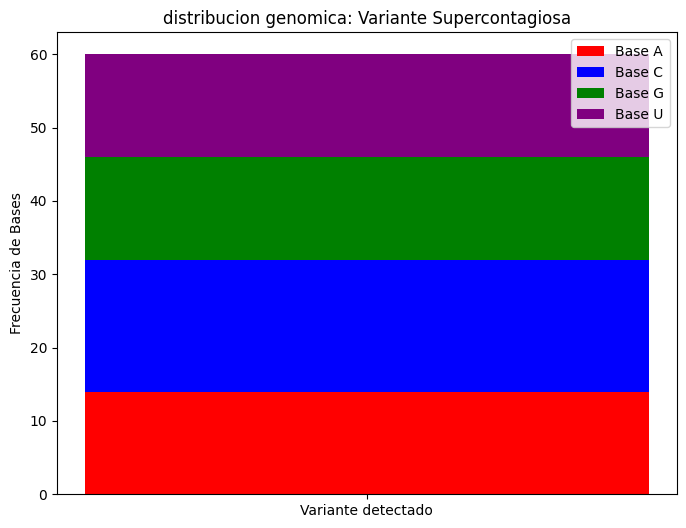

Visualizacion guardada en : variante_detectada_1774988940


  0%|          | 0/1 [00:00<?, ?it/s]

PDF generado (simulador por falta de dependencia del sistema)
Audio generado en variante_detectada_1774988940\alerta_audio.mp3
Adjuntando al correo: reporte_mutaciones.pdf
Adjuntando al correo: grafico_genomico.png
Adjuntando al correo: alerta_audio.mp3
Correo enviado exitosamente a: minecraftheghost69@gmail.com


In [8]:
if __name__ == "__main__":
    try:
        mi_virus = VirusARN("VIRUS-SIGMA-X", "ACGT" * 15)
        posicion = (4.7110, -74.0721)
        
        v_final, logs = simular_evolucion_patogeno(mi_virus, posicion)
        
        nombre_carpeta = f"variante_detectada_{int(time.time())}"
        
        generar_visalizacion(v_final, nombre_carpeta)
        generar_entregables(logs, nombre_carpeta)
        enviar_notificaciones(nombre_carpeta, smtp_password="aazi gzlm aslo kiyf")
        
    except Exception as e:
        print(f"Error Critico: {e}")
            